In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading Datasets

In [3]:
virtual = pd.read_csv("../../data/virtual_events.csv")
real = pd.read_csv("../../data/real_events.csv")

In [4]:
real.describe()

,id,pt_real,y_real,z_gluon,weight
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,30.073175,0.039401,4.970568,8.561418
std,866.169729,30.170103,1.501202,4.939488,5.290617
min,1.000000,0.005092,-5.092144,0.000462,0.001518
25%,750.750000,8.889415,-0.964459,1.520514,4.156885
50%,1500.500000,20.934712,0.044991,3.454818,8.236984
75%,2250.250000,41.474291,1.103602,6.878433,12.674936
max,3000.000000,278.755791,4.629775,38.782019,23.310711


In [5]:
virtual.describe()

,id,pt,y,weight
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,29.667175,-0.050769,-5.040186
std,433.157015,29.408526,1.579329,2.992824
min,1.000000,0.000284,-4.997031,-11.844721
25%,375.750000,8.219215,-1.135975,-7.449911
50%,750.500000,20.260382,-0.034716,-4.966707
75%,1125.250000,42.714615,0.992715,-2.352622
max,1500.000000,224.567861,4.497154,-0.005719


# Born Projection

In [6]:
real["pt"] = real["pt_real"] + real["z_gluon"]
real["y"] = real["y_real"]

In [7]:
events = pd.concat([virtual[["pt","y","weight"]], real[["pt","y","weight"]]])

In [8]:
# export csv
events.to_csv("../../data/combined_events.csv", index=False)

# Visualizing Original Distributions

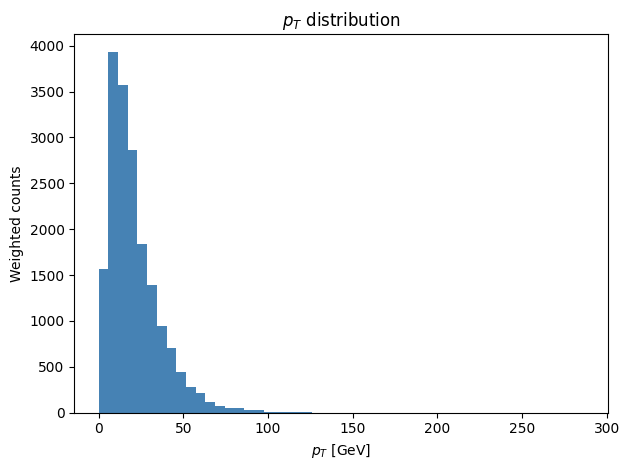

In [9]:
fig, ax = plt.subplots()
ax.hist(events["pt"], bins=50, weights=events["weight"], color="steelblue", edgecolor="none")
ax.set_xlabel("$p_T$ [GeV]")
ax.set_ylabel("Weighted counts")
ax.set_title("$p_T$ distribution")
plt.tight_layout()
plt.savefig("../results/pt_distribution.png", dpi=150)
plt.show()

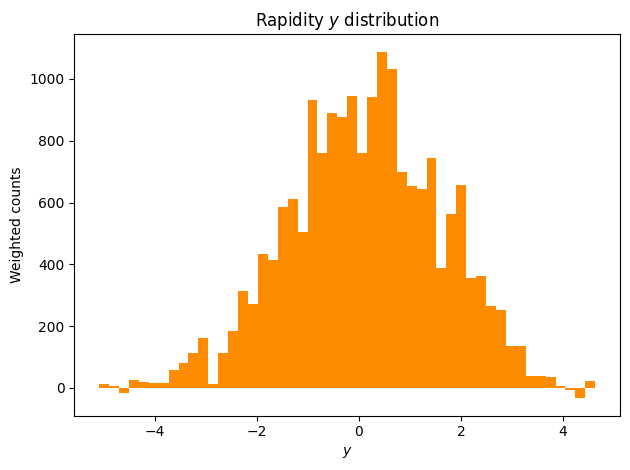

In [10]:
fig, ax = plt.subplots()
ax.hist(events["y"], bins=50, weights=events["weight"], color="darkorange", edgecolor="none")
ax.set_xlabel("$y$")
ax.set_ylabel("Weighted counts")
ax.set_title("Rapidity $y$ distribution")
plt.tight_layout()
plt.savefig("../results/y_distribution.png", dpi=150)
plt.show()

# Cell Resampling

In [ ]:
import sys
# import importlib # for reloading modules during development
# import src.resampling as resample_mod
# importlib.reload(resample_mod)
sys.path.insert(0, "..")

from src.resampling import cell_resampling

combined_events = pd.read_csv("../../data/combined_events.csv")
resampled = cell_resampling(combined_events)
resampled

,pt,y,weight
0,70.236537,-1.323280,0.239679
1,12.799335,0.707796,2.397263
2,57.363564,-1.634182,0.377124
3,50.325187,-0.811363,0.123933
4,45.102483,-0.166457,0.123315
...,...,...,...
4495,33.413959,-1.050079,7.304024
4496,39.341053,-2.653858,5.429906
4497,80.216497,-1.063696,1.435781
4498,31.058749,1.007277,6.015705


## Verification

In [23]:
n_negative_before = (events["weight"] < 0).sum()
n_negative_after  = (resampled["weight"] < 0).sum()
weight_before = events["weight"].sum()
weight_after  = resampled["weight"].sum()

print(f"Negative weights before: {n_negative_before}")
print(f"Negative weights after:  {n_negative_after}")
print(f"Total weight before: {weight_before:.4f}")
print(f"Total weight after:  {weight_after:.4f}")
assert n_negative_after == 0, "Resampling failed: negative weights remain"
assert np.isclose(weight_before, weight_after, rtol=1e-6), "Total weight not conserved"
print("\nAll checks passed.")

Negative weights before: 1500
Negative weights after:  0
Total weight before: 18123.9747
Total weight after:  18123.9747

All checks passed.


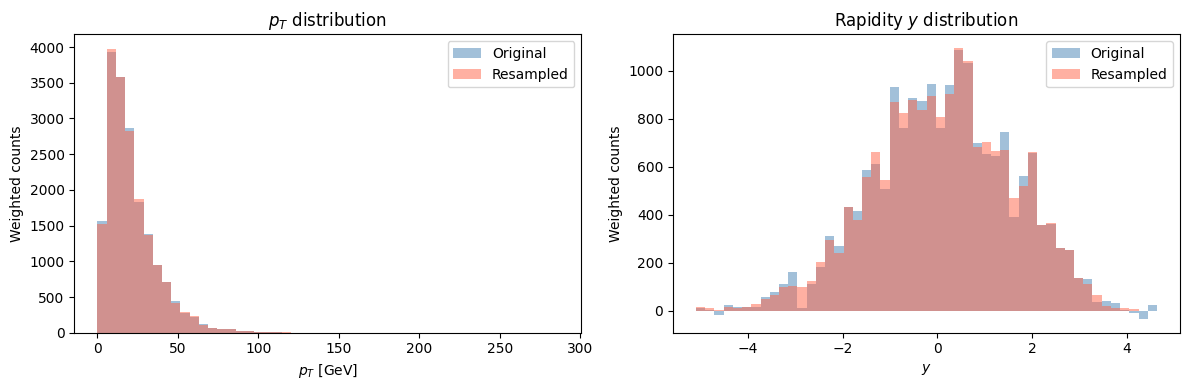

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(events["pt"], bins=50, weights=events["weight"],
             alpha=0.5, label="Original", color="steelblue")
axes[0].hist(resampled["pt"], bins=50, weights=resampled["weight"],
             alpha=0.5, label="Resampled", color="tomato")
axes[0].set_xlabel("$p_T$ [GeV]")
axes[0].set_ylabel("Weighted counts")
axes[0].set_title("$p_T$ distribution")
axes[0].legend()

axes[1].hist(events["y"], bins=50, weights=events["weight"],
             alpha=0.5, label="Original", color="steelblue")
axes[1].hist(resampled["y"], bins=50, weights=resampled["weight"],
             alpha=0.5, label="Resampled", color="tomato")
axes[1].set_xlabel("$y$")
axes[1].set_ylabel("Weighted counts")
axes[1].set_title("Rapidity $y$ distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/resampled_distributions.png", dpi=150)
plt.show()